# IADD Traffic Detection — YOLOv11 **Run 3**

What's new vs run 2:
- **Leakage-free split BY VIDEO** (train/val/test are disjoint videos) → honest numbers.
- A real **labelled test set** (cell 9 reports the headline metric on it).


## 1. Check the GPU

In [1]:
!nvidia-smi

Sun Aug  2 15:05:55 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. Install Ultralytics

In [2]:
!pip install -q ultralytics
import ultralytics; ultralytics.checks()

Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 46.7/112.6 GB disk)


## 3. Mount Google Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 4. Unzip the dataset into Colab
Re-run this after any reconnect (Colab's local disk is wiped; Drive survives).

In [4]:
!rm -rf /content/iadd_subset_v3
!unzip -q "/content/drive/MyDrive/iadd_subset_v3.zip" -d /content
!ls /content/iadd_subset_v3

data.yaml  images  labels


## 5. Confirm data.yaml (note: it now has train / val / test)

In [5]:
yaml_text = """path: /content/iadd_subset_v3
train: images/train
val: images/val
test: images/test

nc: 6
names:
  0: person
  1: car
  2: motorcycle
  3: bus
  4: truck
  5: traffic_light
"""
with open('/content/iadd_subset_v3/data.yaml', 'w') as f:
    f.write(yaml_text)
print(open('/content/iadd_subset_v3/data.yaml').read())

path: /content/iadd_subset_v3
train: images/train
val: images/val
test: images/test

nc: 6
names:
  0: person
  1: car
  2: motorcycle
  3: bus
  4: truck
  5: traffic_light



## 6. Train (auto fresh-or-resume)

In [ ]:
from ultralytics import YOLO
import os

MODEL = 'yolo11s.pt'
BATCH = 16
IMGSZ = 960

DRIVE_PROJECT = '/content/drive/MyDrive/iadd_runs'
RUN_NAME      = 'run3'
DATA          = '/content/iadd_subset_v3/data.yaml'
CKPT          = f'{DRIVE_PROJECT}/{RUN_NAME}/weights/last.pt'

if os.path.exists(CKPT):
    print('Checkpoint found on Drive -> RESUMING:', CKPT)
    model = YOLO(CKPT)
    results = model.train(resume=True)
else:
    print('No checkpoint -> starting a FRESH run with', MODEL)
    model = YOLO(MODEL)
    results = model.train(
        data=DATA, epochs=150, patience=20, imgsz=IMGSZ, batch=BATCH,
        project=DRIVE_PROJECT, name=RUN_NAME, exist_ok=True, plots=True,
    )


Checkpoint found on Drive -> RESUMING: /content/drive/MyDrive/iadd_runs/run3/weights/last.pt
Ultralytics 8.4.114 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/iadd_subset_v3/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=960, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, mod

## 7. (Optional) Watch progress
Prints the metrics table for every epoch finished so far — handy to see the trend
while training, or after a disconnect.

In [ ]:
import pandas as pd
csv = '/content/drive/MyDrive/iadd_runs/run3/results.csv'
df = pd.read_csv(csv)
df.columns = [c.strip() for c in df.columns]
print('epochs done:', len(df))
df[['epoch','metrics/mAP50(B)','metrics/mAP50-95(B)',
    'metrics/precision(B)','metrics/recall(B)']].tail(10)


## 8. Evaluate on VALIDATION + make all plots  ← run ANY time, even mid-training

Validates the best checkpoint so far and writes the confusion matrix + P/R/PR/F1
curves to `iadd_runs/run3_val/`, then shows them and prints the metrics
(with a per-class breakdown in the log).

In [6]:
from ultralytics import YOLO

best = YOLO('/content/drive/MyDrive/iadd_runs/run3/weights/best.pt')
DATA = '/content/iadd_subset_v3/data.yaml'
CONFS = [0.25, 0.35, 0.434, 0.50, 0.60]   # 0.434 = F1 peak from run3_test curve

print('='*70)
print('VAL — confidence sweep')
print(f"{'conf':<8}{'mAP50':<10}{'mAP50-95':<12}{'P':<10}{'R':<10}")
print('='*70)
for c in CONFS:
    m = best.val(data=DATA, split='val', conf=c, plots=False, verbose=False)
    print(f"{c:<8}{m.box.map50:<10.4f}{m.box.map:<12.4f}{m.box.mp:<10.4f}{m.box.mr:<10.4f}")
print('='*70)

# final VAL at F1-optimal conf — saves plots to Drive, prints per-class table
print('\n>>> FINAL VAL at conf=0.434 (per-class below, plots saved to Drive)\n')
m = best.val(data=DATA, split='val', conf=0.434, plots=True, verbose=True,
             project='/content/drive/MyDrive/iadd_runs', name='run3_val_tuned',
             exist_ok=True)
print(f"\nVAL @0.434 -> mAP50={m.box.map50:.4f} | mAP50-95={m.box.map:.4f} | "
      f"P={m.box.mp:.4f} | R={m.box.mr:.4f}")
print('plots saved -> /content/drive/MyDrive/iadd_runs/run3_val_tuned')

VAL — confidence sweep
conf    mAP50     mAP50-95    P         R         
Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,415,122 parameters, 0 gradients, 21.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2759.9±928.7 MB/s, size: 147.5 KB)
val: Scanning /content/iadd_subset_v3/labels/val... 2448 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2448/2448 2.2Kit/s 1.1s
val: New cache created: /content/iadd_subset_v3/labels/val.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 153/153 4.1it/s 37.5s
                   all       2448      17846      0.762      0.716      0.707      0.578
Speed: 1.3ms preprocess, 10.2ms inference, 0.0ms loss, 1.1ms postprocess per image
0.25    0.7070    0.5781      0.7623    0.7161    
Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.

## 9. ★ Evaluate on the TEST set — the HONEST headline number for the paper

The test videos were never seen in training, so this is the number to report.
Also runs any time from the best checkpoint so far.

In [7]:
print('='*70)
print('TEST — confidence sweep')
print(f"{'conf':<8}{'mAP50':<10}{'mAP50-95':<12}{'P':<10}{'R':<10}")
print('='*70)
for c in CONFS:
    mt = best.val(data=DATA, split='test', conf=c, plots=False, verbose=False)
    print(f"{c:<8}{mt.box.map50:<10.4f}{mt.box.map:<12.4f}{mt.box.mp:<10.4f}{mt.box.mr:<10.4f}")
print('='*70)

# final TEST at F1-optimal conf — saves plots to Drive, prints per-class table
print('\n>>> FINAL TEST at conf=0.434 (per-class below, plots saved to Drive)\n')
mt = best.val(data=DATA, split='test', conf=0.434, plots=True, verbose=True,
              project='/content/drive/MyDrive/iadd_runs', name='run3_test_tuned',
              exist_ok=True)
print(f"\nTEST @0.434 -> mAP50={mt.box.map50:.4f} | mAP50-95={mt.box.map:.4f} | "
      f"P={mt.box.mp:.4f} | R={mt.box.mr:.4f}")
print('plots saved -> /content/drive/MyDrive/iadd_runs/run3_test_tuned')

TEST — confidence sweep
conf    mAP50     mAP50-95    P         R         
Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
WARNING ⚠️ val: Slow image access detected (ping: 0.0±0.0 ms, read: 29.7±21.2 MB/s, size: 93.3 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /content/iadd_subset_v3/labels/test... 3007 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3007/3007 604.1it/s 5.0s
val: New cache created: /content/iadd_subset_v3/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 188/188 3.6it/s 51.7s
                   all       3007      17143      0.736       0.77      0.722      0.579
Speed: 1.3ms preprocess, 12.4ms inference, 0.0ms loss, 1.0ms postprocess per image
0.25    0.7224    0.5793      0.7361    0.7697    
Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+

## 10. Inference demo (uses the good confidence threshold ~0.47)


0: 544x960 2 persons, 12 cars, 13.7ms
1: 544x960 4 persons, 6 cars, 1 motorcycle, 13.7ms
2: 544x960 1 person, 9 cars, 1 motorcycle, 13.7ms
3: 544x960 1 person, 8 cars, 1 motorcycle, 13.7ms
4: 544x960 2 persons, 10 cars, 1 motorcycle, 13.7ms
5: 544x960 2 persons, 6 cars, 1 motorcycle, 13.7ms
6: 544x960 4 cars, 13.7ms
7: 544x960 5 cars, 13.7ms
Speed: 3.9ms preprocess, 13.7ms inference, 1.0ms postprocess per image at shape (1, 3, 544, 960)
Results saved to /content/runs/detect/predict


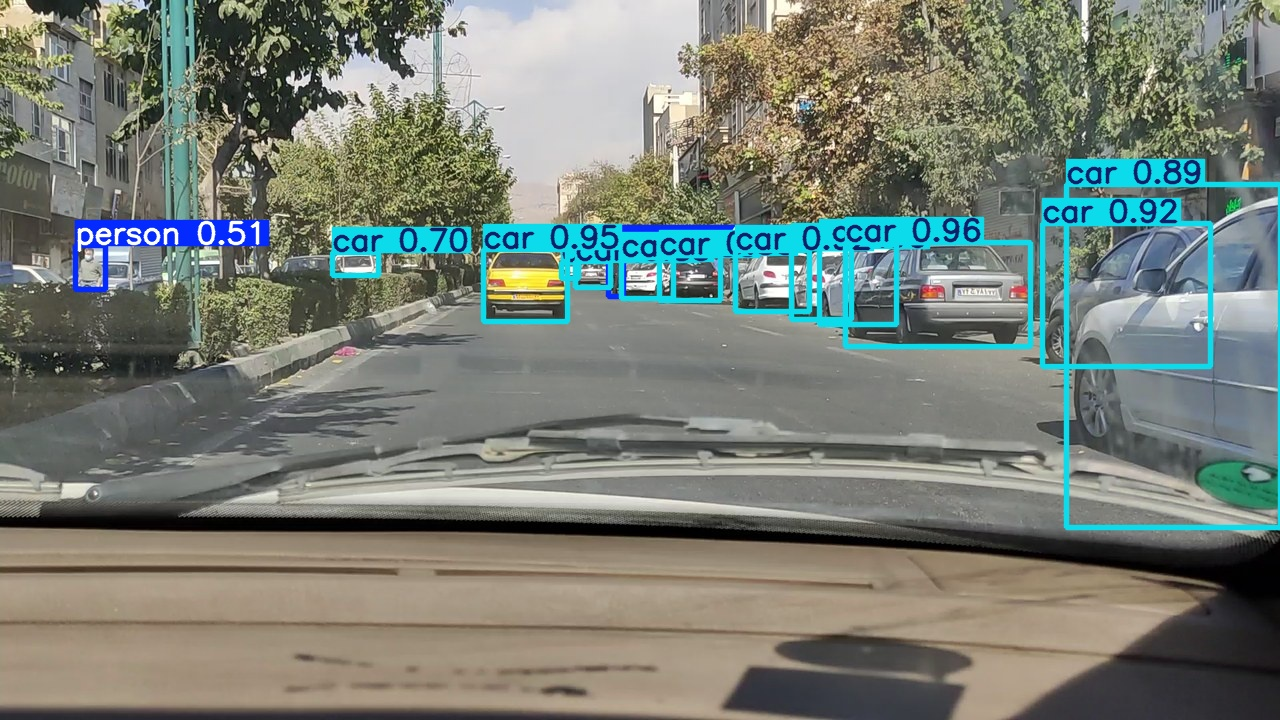

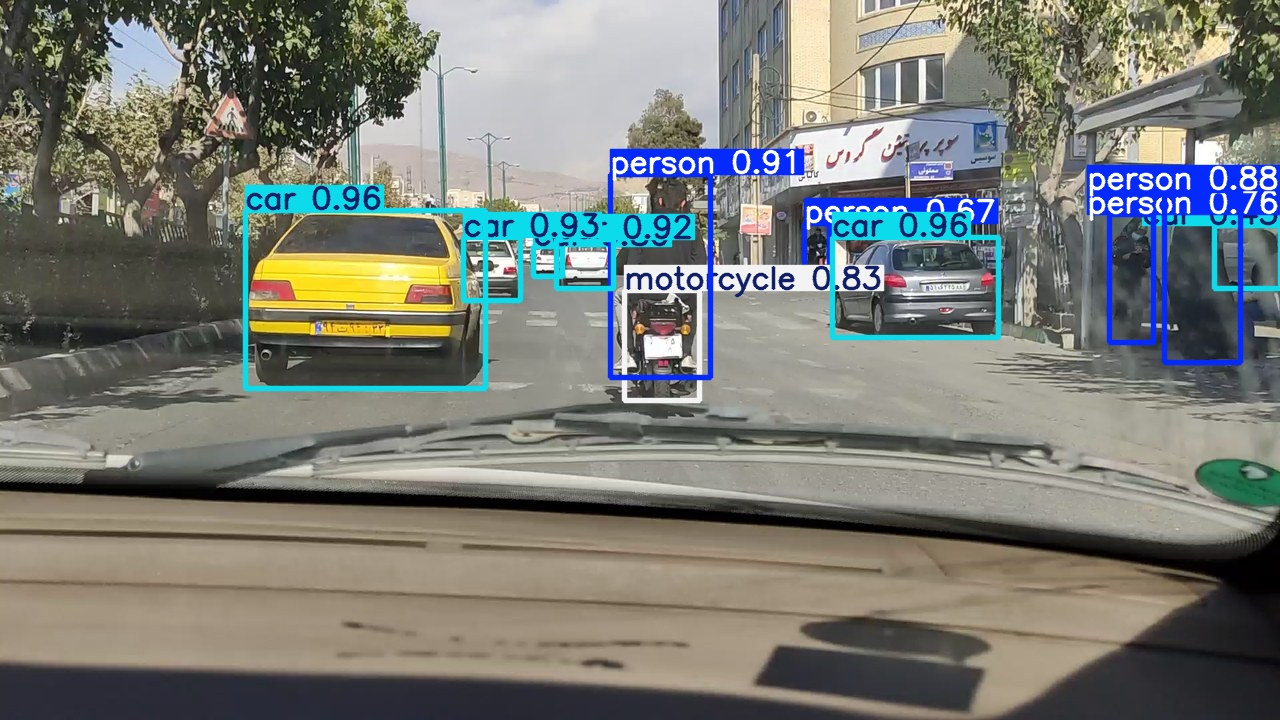

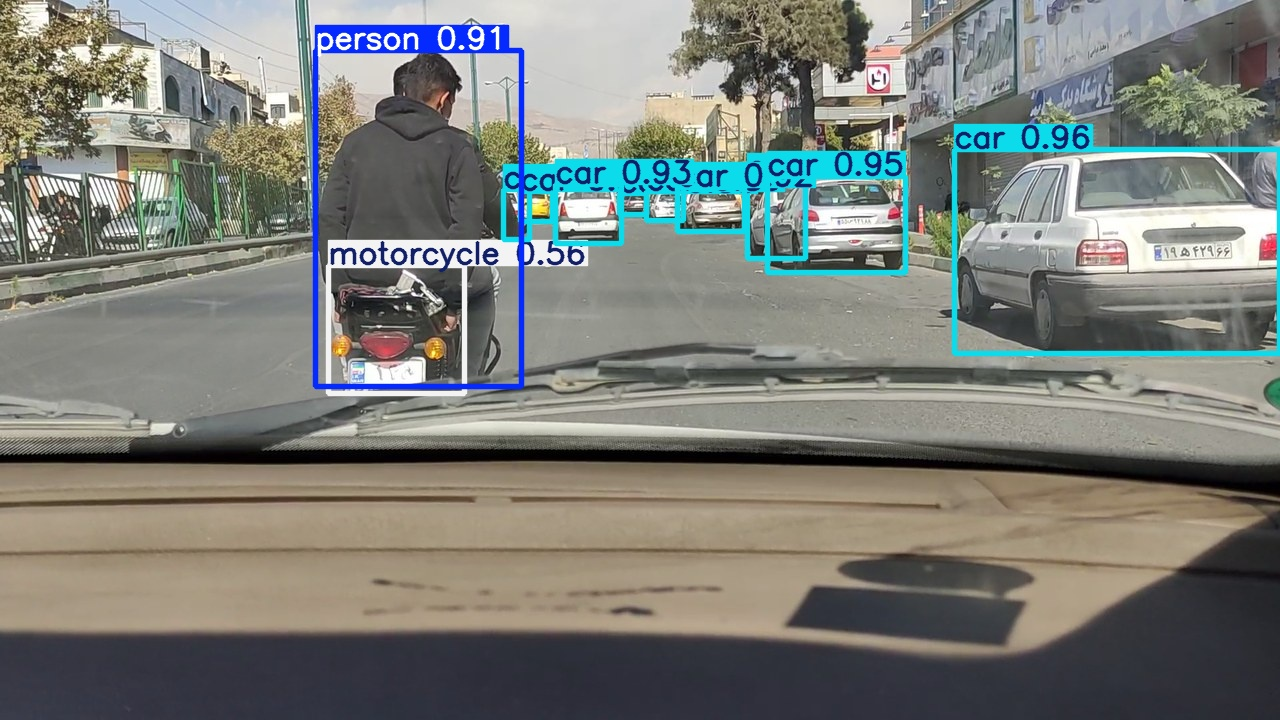

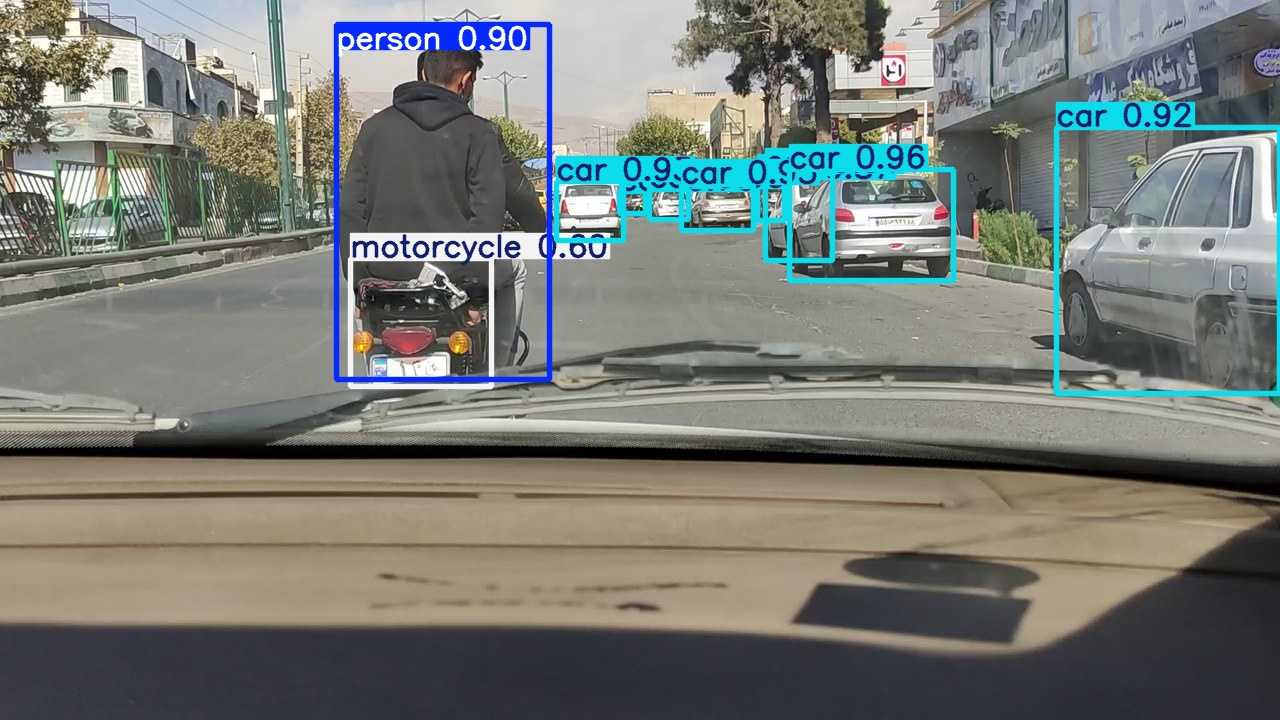

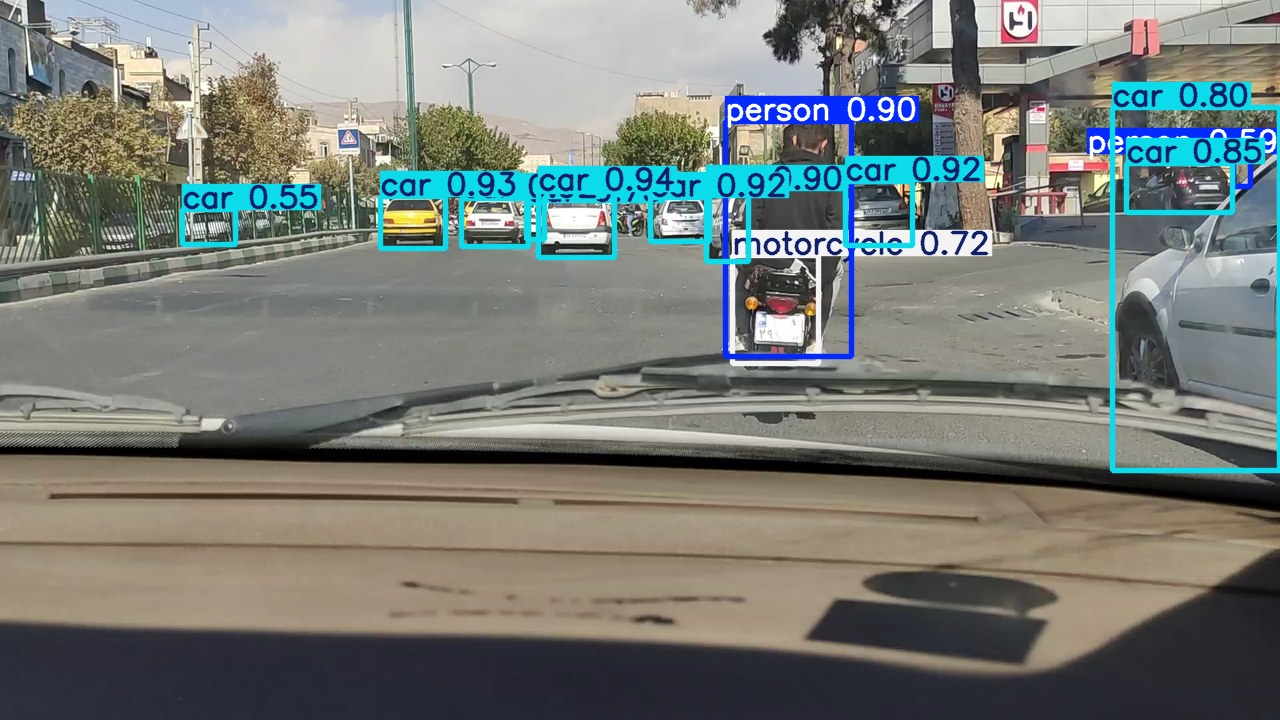

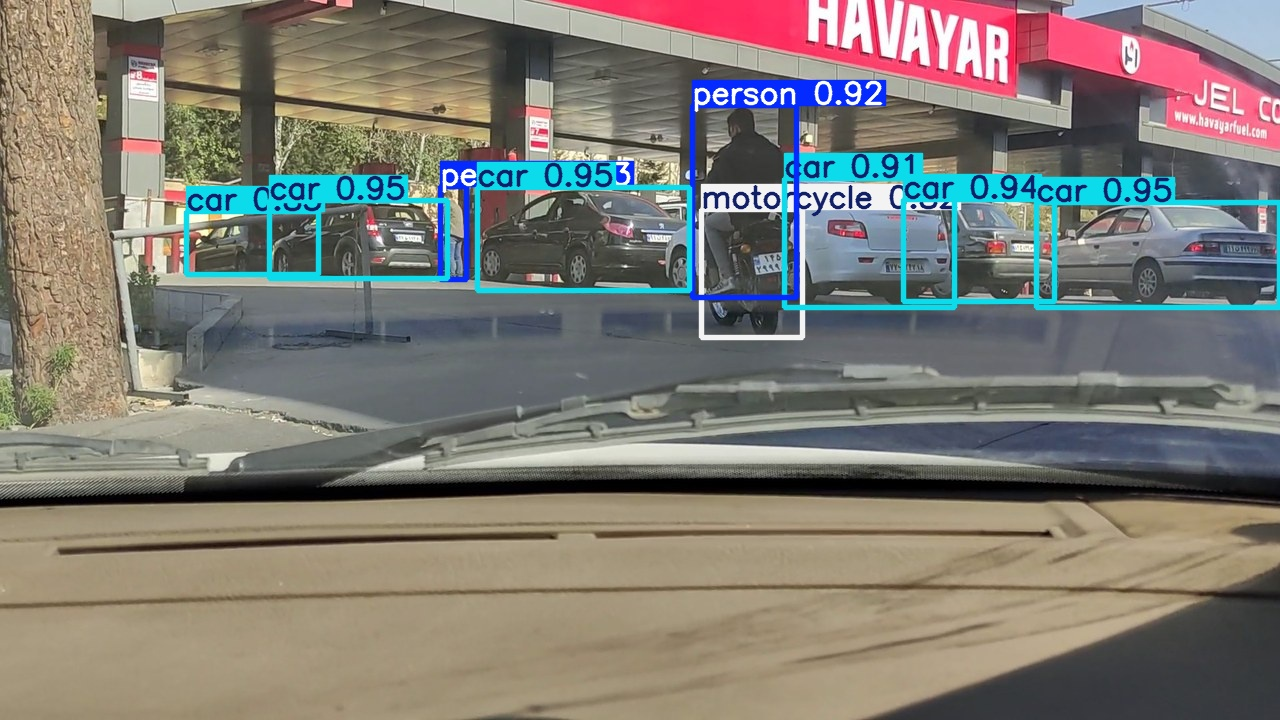

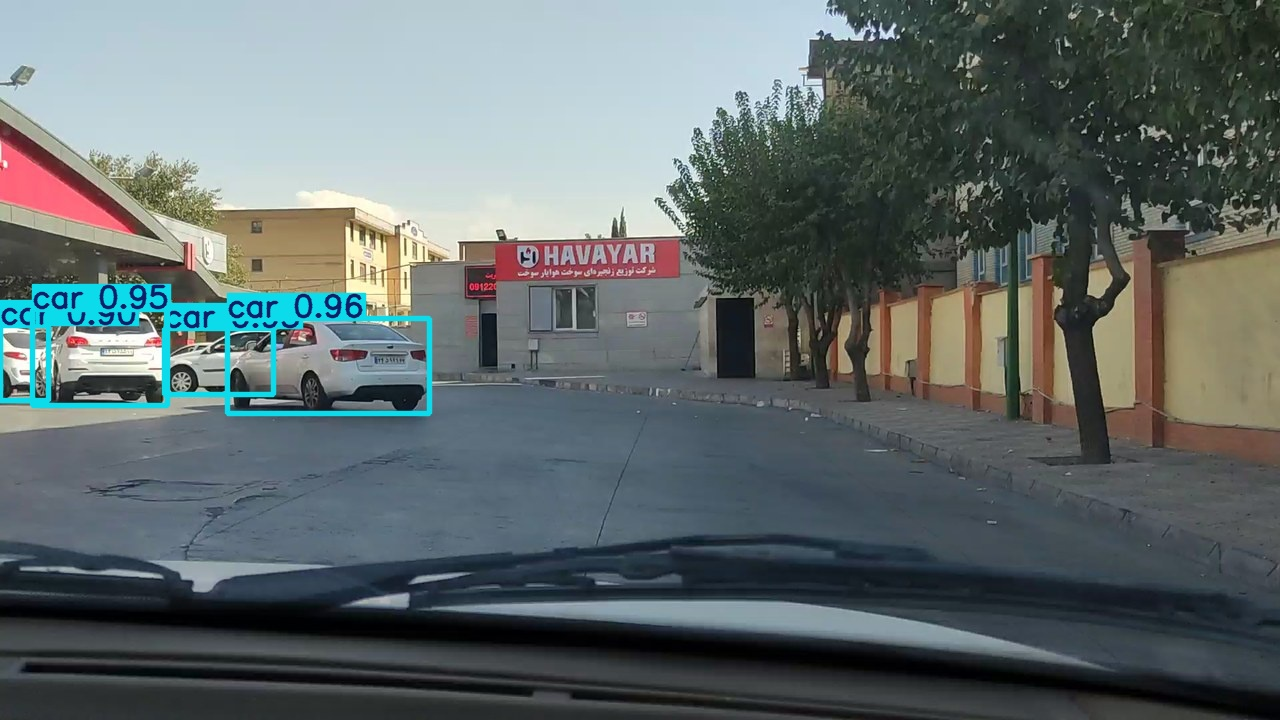

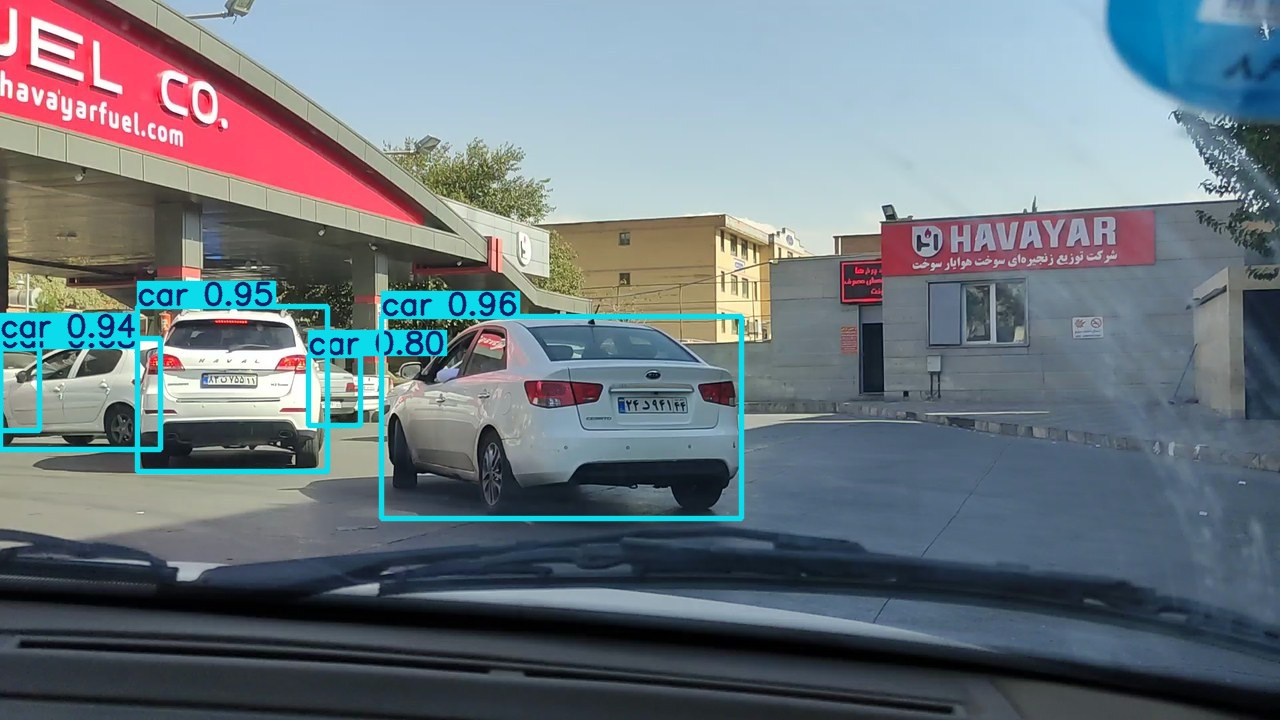

In [8]:
import glob
from IPython.display import Image, display
imgs = sorted(glob.glob('/content/iadd_subset_v3/images/test/*.jpg'))[:8]
pred = best.predict(imgs, conf=0.434, save=True)
for p in sorted(glob.glob(f'{pred[0].save_dir}/*.jpg'))[:8]:
    display(Image(filename=p, width=760))


---
All results are on Drive: `iadd_runs/run3/` (training + weights),
`run3_val/` and `run3_test/` (evaluation plots). To record this version on GitHub,
copy them into `colab/runs/run-3/` and commit.